# Plot PARSIVEL Matrices

Produces PARSIVEL (Particle Size and Velocity) fall speed vs. diameter matrices for three storm types:
- **S/SWIVT** (South/Southwest Inverted Trough)
- **Frontal**
- **NW Postfrontal**

Fall speed relations from Locatelli and Hobbs (1974) and Berry and Pranger (1974) are overlaid to aid particle type identification (aggregates of dendrites, lump graupel, and rain).

**Prerequisites:** Run `Parsivel_Availability.ipynb` before this notebook to generate the required `.npy` data files.

**Author:** Michael Wasserstein and David Kingsmill
**Date:** 17 Feb 2024

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pyart
import sys
import os


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# ============================================================
# USER CONFIGURATION — Update these paths for your environment
# ============================================================

# Site name and symbol
site = 'Highland'
site_symbol = 'HGH'

# Load in all the imputs specific to Highland
from Parsivel_inputs_hgh import *
from Parsivel_inputs_hgh import Vaggr_corrected as Vaggr_corrected_hgh
from Parsivel_inputs_hgh import Vgr_corrected as Vgr_corrected_hgh
from Parsivel_inputs_hgh import Vbp_corrected as Vbp_corrected_hgh

# Path to directory containing preprocessed PARSIVEL data (.npy files)
# Expected structure: data_path/<Site>/PARSIVEL_Matrix_<event_type>.npy
data_path = 'Data/PARSIVEL/'

# Path to directory for saving output figures
output_path = 'Fig/'

print(f'Working on Parsivel plots for {site}')


Working on Parsivel plots for Highland


In [3]:
# User defined type of event
event_type = 'SIVT'

In [4]:
def load_data(site, event_type):
    """
    Load preprocessed PARSIVEL matrix data for a given site and event type.
    Must have run the script Generate_PARSIVEL_Datasets.py

    Parameters
    ----------
    site : str
        Site name (e.g., 'Alta', 'Highland')
    event_type : str
        Storm classification type ('SIVT', 'FR', 'PF', or 'ALL')

    Returns
    -------
    accum_matrix : np.ndarray
        Accumulated PARSIVEL fall speed vs. diameter matrix
    """
    site_data_path = os.path.join(data_path, site)
    accum_matrix   = np.load(os.path.join(site_data_path, f'PARSIVEL_Matrix_{event_type}.npy'))
    return accum_matrix

In [5]:
# Load in stored data for the classifications
# sivt
accum_matrix_Highland_sivt = load_data('Highland', 'SIVT')

# fr
accum_matrix_Highland_fr = load_data('Highland', 'FR')

# pf
accum_matrix_Highland_pf = load_data('Highland', 'PF')


In [6]:
# Plot settings
vmin = 1
vmax = 5
extend = 'max'

/scratch/local/u1371671/11433418/ipykernel_178962/3999457169.py:15: RuntimeWarning: divide by zero encountered in log10
  np.log10(accum_matrix_Highland_sivt[:, 8:]), cmap=cmap, vmin=vmin, vmax=vmax)
/scratch/local/u1371671/11433418/ipykernel_178962/3999457169.py:32: RuntimeWarning: divide by zero encountered in log10
  np.log10(accum_matrix_Highland_fr[:, 8:]), cmap=cmap, vmin=vmin, vmax=vmax)
/scratch/local/u1371671/11433418/ipykernel_178962/3999457169.py:48: RuntimeWarning: divide by zero encountered in log10
  np.log10(accum_matrix_Highland_pf[:, 8:]), cmap=cmap, vmin=vmin, vmax=vmax)


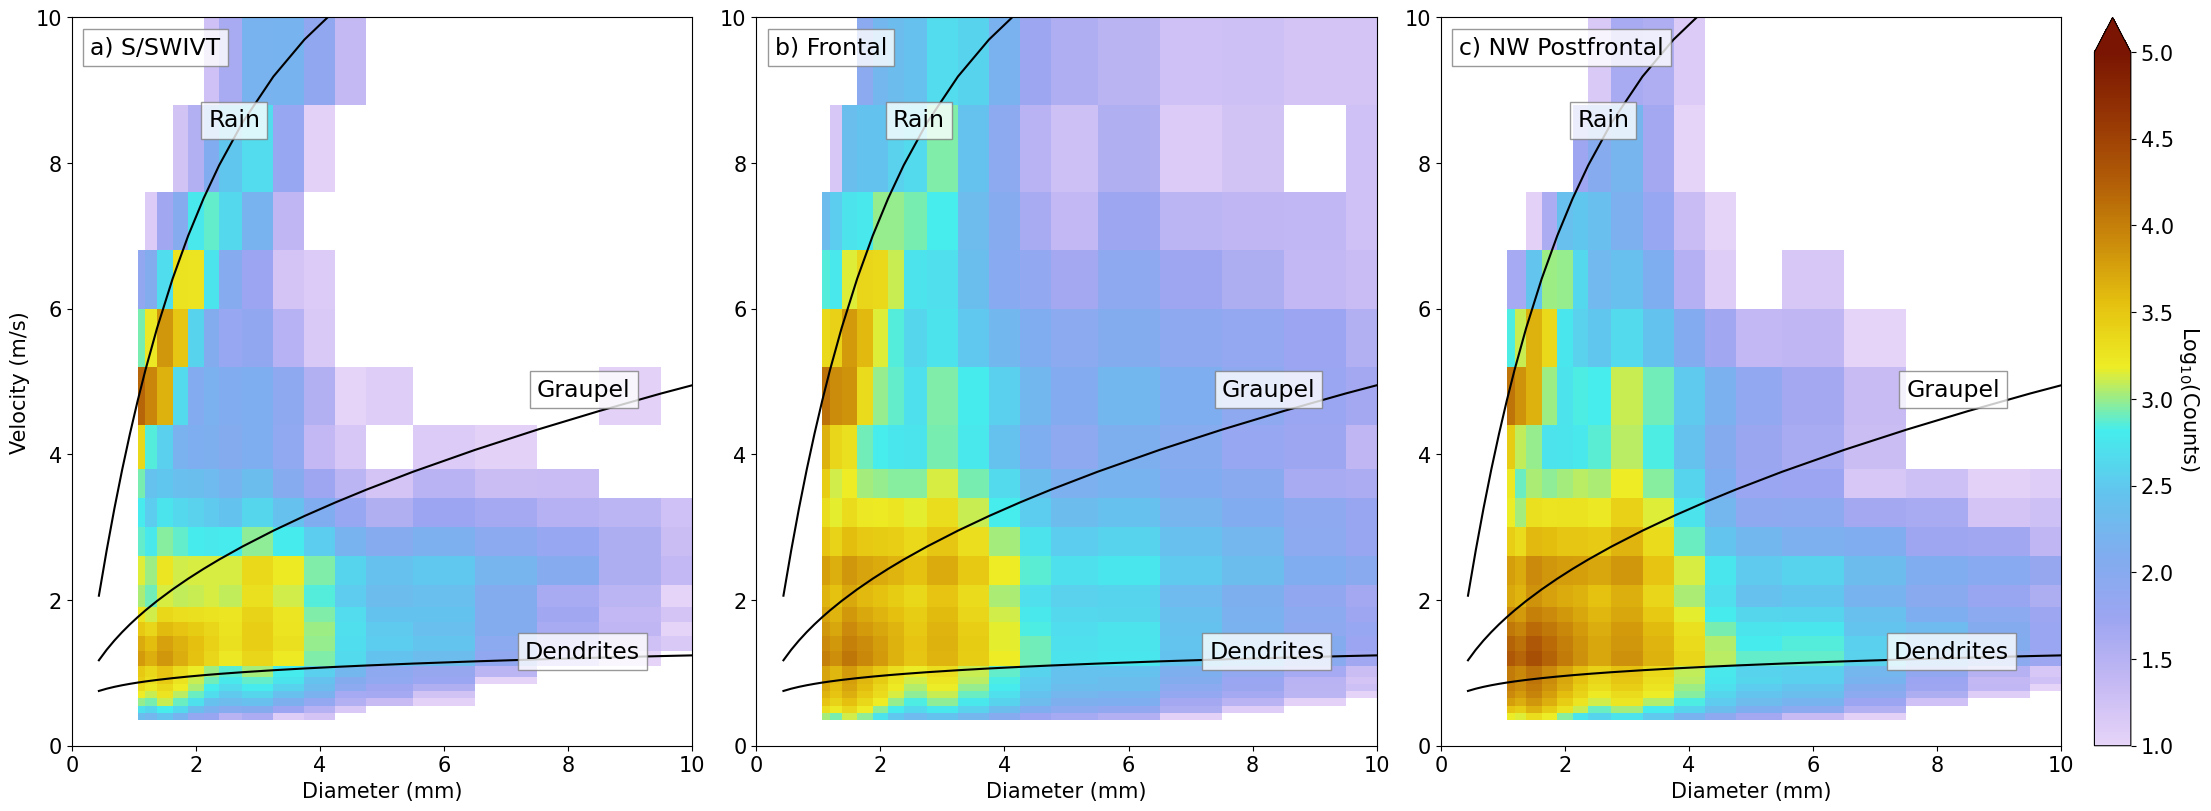

Done plotting matrix


In [7]:
##############################################################
############## Plot the Parsivel Matrix ######################
##############################################################
cmap = plt.get_cmap('pyart_LangRainbow12')
cmap.set_under('none')

fig, axs = plt.subplots(1, 3, figsize=(22, 8), facecolor='white', edgecolor='k', constrained_layout=True)

ax1 = axs.ravel()[0]
ax2 = axs.ravel()[1]
ax3 = axs.ravel()[2]

############################### ax1: S/SWIVT ###############################
plot = ax1.pcolormesh(parsivel_D[8:] + (parsivel_deltaD[8:] / 2), parsivel_V + (parsivel_deltaV / 2),
                      np.log10(accum_matrix_Highland_sivt[:, 8:]), cmap=cmap, vmin=vmin, vmax=vmax)

# Add lines for hydrometeor traces
ax1.plot(parsivel_D[3:30], Vaggr_corrected_hgh[3:30], color='k')  # Locatelli and Hobbs 1974: aggregates of dendrites
ax1.plot(parsivel_D[3:30], Vgr_corrected_hgh[3:30],   color='k')  # Locatelli and Hobbs 1974: lump graupel
ax1.plot(parsivel_D[3:30], Vbp_corrected_hgh[3:30],   color='k')  # Berry and Pranger 1974: rain

# Plot settings
ax1.set_ylim(0, 10)
ax1.set_xlim(0, 10)
ax1.set_xticks(np.arange(0, 11, 2), labels=np.arange(0, 11, 2), fontsize=15)
ax1.set_yticks(np.arange(0, 11, 2), labels=np.arange(0, 11, 2), fontsize=15)
ax1.set_xlabel('Diameter (mm)', fontsize=15)
ax1.set_ylabel('Velocity (m/s)', fontsize=15)

############################### ax2: Frontal ###############################
plot = ax2.pcolormesh(parsivel_D[8:] + (parsivel_deltaD[8:] / 2), parsivel_V + (parsivel_deltaV / 2),
                      np.log10(accum_matrix_Highland_fr[:, 8:]), cmap=cmap, vmin=vmin, vmax=vmax)

# Add lines for hydrometeor traces
ax2.plot(parsivel_D[3:30], Vaggr_corrected_hgh[3:30], color='k')  # Locatelli and Hobbs 1974: aggregates of dendrites
ax2.plot(parsivel_D[3:30], Vgr_corrected_hgh[3:30],   color='k')  # Locatelli and Hobbs 1974: lump graupel
ax2.plot(parsivel_D[3:30], Vbp_corrected_hgh[3:30],   color='k')  # Berry and Pranger 1974: rain

# Plot settings
ax2.set_ylim(0, 10)
ax2.set_xlim(0, 10)
ax2.set_xticks(np.arange(0, 11, 2), labels=np.arange(0, 11, 2), fontsize=15)
ax2.set_yticks(np.arange(0, 11, 2), labels=np.arange(0, 11, 2), fontsize=15)
ax2.set_xlabel('Diameter (mm)', fontsize=15)

############################### ax3: NW Postfrontal ###############################
plot = ax3.pcolormesh(parsivel_D[8:] + (parsivel_deltaD[8:] / 2), parsivel_V + (parsivel_deltaV / 2),
                      np.log10(accum_matrix_Highland_pf[:, 8:]), cmap=cmap, vmin=vmin, vmax=vmax)

# Add lines for hydrometeor traces
ax3.plot(parsivel_D[3:30], Vaggr_corrected_hgh[3:30], color='k')  # Locatelli and Hobbs 1974: aggregates of dendrites
ax3.plot(parsivel_D[3:30], Vgr_corrected_hgh[3:30],   color='k')  # Locatelli and Hobbs 1974: lump graupel
ax3.plot(parsivel_D[3:30], Vbp_corrected_hgh[3:30],   color='k')  # Berry and Pranger 1974: rain

# Plot settings
ax3.set_ylim(0, 10)
ax3.set_xlim(0, 10)
ax3.set_xticks(np.arange(0, 11, 2), labels=np.arange(0, 11, 2), fontsize=15)
ax3.set_yticks(np.arange(0, 11, 2), labels=np.arange(0, 11, 2), fontsize=15)
ax3.set_xlabel('Diameter (mm)', fontsize=15)

# Hydrometeor type labels
props = dict(boxstyle='square', facecolor='white', alpha=0.8, ec='gray')
for ax in [ax1, ax2, ax3]:
    ax.text(0.22, 0.85, 'Rain',      transform=ax.transAxes, bbox=props, fontsize=17, zorder=20)
    ax.text(0.75, 0.48, 'Graupel',   transform=ax.transAxes, bbox=props, fontsize=17, zorder=20)
    ax.text(0.73, 0.12, 'Dendrites', transform=ax.transAxes, bbox=props, fontsize=17, zorder=20)

# Panel labels
ax1.text(0.03, 0.95, 'a) S/SWIVT',       transform=ax1.transAxes, bbox=props, fontsize=17, zorder=20)
ax2.text(0.03, 0.95, 'b) Frontal',        transform=ax2.transAxes, bbox=props, fontsize=17, zorder=20)
ax3.text(0.03, 0.95, 'c) NW Postfrontal', transform=ax3.transAxes, bbox=props, fontsize=17, zorder=20)

# Colorbar
cbar = fig.colorbar(plot, extend=extend, ax=axs, pad=0.01, shrink=1, fraction=0.1)
cbar.set_label('Log$_{10}$(Counts)', rotation=270, labelpad=20, fontsize=15)
cbar.ax.tick_params(labelsize=15)

# Save and show figure
plt.savefig(os.path.join(output_path, 'all_parsivel_matrix_HIGHLAND_v2.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Done plotting matrix')
